# 04 - Hyperparameter Tuning dan Feature Selection

Notebook ini berisi tahap hyperparameter tuning dan feature selection pada proyek prediksi churn pelanggan.

Tahap ini dilakukan setelah direct modeling dan modeling dengan preprocessing. Tujuannya adalah mencari konfigurasi model yang lebih optimal melalui proses tuning, kemudian mengevaluasi kembali performa model pada data uji.

Tahapan utama pada notebook ini meliputi:
- load dataset,
- train-test split dengan proporsi yang sama,
- feature engineering,
- handling outlier,
- preprocessing data,
- analisis feature importance,
- feature selection,
- hyperparameter tuning,
- evaluasi model hasil tuning,
- penyimpanan best estimator dan best parameters.

## Import Library

Library yang digunakan mencakup pengolahan data, preprocessing, feature selection, hyperparameter tuning, evaluasi model, visualisasi, dan penyimpanan model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## Setup Path Project

Path project disiapkan agar dataset, hasil evaluasi, hasil tuning, visualisasi, dan model dapat disimpan pada folder yang sesuai.

In [2]:
# Mengatur folder utama project
PROJECT_DIR = Path.cwd()

# Jika notebook dijalankan dari folder notebooks, arahkan ke folder utama project
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

# Path dataset dan folder output
DATA_PATH = PROJECT_DIR / "data" / "raw" / "Sales - Marketing customer dataset.csv"

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
MODELS_DIR = PROJECT_DIR / "models"

# Membuat folder jika belum tersedia
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/cahya/Project/UAS-BENGKOD-Churn-Prediction/data/raw/Sales - Marketing customer dataset.csv')

## Load Dataset

Dataset dibaca dari folder `data/raw`. Dataset yang digunakan sama seperti tahap sebelumnya agar hasil antar skenario dapat dibandingkan secara adil.

In [3]:
# Membaca dataset
df = pd.read_csv(DATA_PATH)

df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
# Melihat ukuran dataset
df.shape

(15000, 30)

In [5]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## Handling Duplikasi

Data duplikat dicek dan dihapus jika ditemukan. Tahap ini dilakukan sebelum pemodelan agar tidak ada data yang tercatat lebih dari satu kali.

In [6]:
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat sebelum handling:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Jumlah data setelah handling duplikasi:", df.shape[0])

Jumlah data duplikat sebelum handling: 0
Jumlah data setelah handling duplikasi: 15000


## Menentukan Fitur dan Target

Kolom `churn` digunakan sebagai target prediksi. Seluruh kolom selain `churn` digunakan sebagai fitur awal sebelum dilakukan feature engineering dan preprocessing.

In [7]:
# Menentukan target dan fitur
y = df["churn"]
X = df.drop(columns=["churn"])

print("Jumlah data:", X.shape[0])
print("Jumlah fitur awal:", X.shape[1])
print("\nDistribusi target:")
print(y.value_counts())

Jumlah data: 15000
Jumlah fitur awal: 29

Distribusi target:
churn
0    12702
1     2298
Name: count, dtype: int64


## Train-Test Split

Data dibagi menjadi data latih dan data uji dengan proporsi 80:20. Pembagian dilakukan sebelum preprocessing dan tuning untuk menghindari data leakage.

Data latih digunakan dalam proses preprocessing, feature selection, dan hyperparameter tuning. Data uji hanya digunakan pada evaluasi akhir setelah tuning selesai.

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_raw: (12000, 29)
X_test_raw: (3000, 29)
y_train: (12000,)
y_test: (3000,)


## Feature Engineering

Kolom tanggal tidak langsung digunakan dalam bentuk mentah. Pada tahap ini dibuat beberapa fitur baru yang lebih mudah digunakan model.

Fitur yang dibuat:
- `customer_tenure_days`
- `days_since_last_purchase`
- `signup_month`
- `last_purchase_month`
- `has_coupon_code`

Kolom `customer_id`, `signup_date`, `last_purchase_date`, dan `coupon_code` dihapus karena sudah tidak digunakan secara langsung.

In [9]:
# Reference date hanya dihitung dari data latih
reference_date = pd.to_datetime(X_train_raw["last_purchase_date"], errors="coerce").max()

reference_date

Timestamp('2025-03-10 00:00:00')

In [10]:
def create_customer_features(data, reference_date):
    """
    Membuat fitur tambahan dari kolom tanggal dan coupon_code.
    """
    data = data.copy()
    
    data["signup_date"] = pd.to_datetime(data["signup_date"], errors="coerce")
    data["last_purchase_date"] = pd.to_datetime(data["last_purchase_date"], errors="coerce")
    
    data["customer_tenure_days"] = (
        data["last_purchase_date"] - data["signup_date"]
    ).dt.days
    
    data["days_since_last_purchase"] = (
        reference_date - data["last_purchase_date"]
    ).dt.days
    
    data["signup_month"] = data["signup_date"].dt.month
    data["last_purchase_month"] = data["last_purchase_date"].dt.month
    
    data["has_coupon_code"] = data["coupon_code"].notna().astype(int)
    
    columns_to_drop = [
        "customer_id",
        "signup_date",
        "last_purchase_date",
        "coupon_code"
    ]
    
    data = data.drop(columns=columns_to_drop, errors="ignore")
    
    return data

In [11]:
# Menerapkan feature engineering ke data latih dan data uji
X_train_fe = create_customer_features(X_train_raw, reference_date)
X_test_fe = create_customer_features(X_test_raw, reference_date)

print("Shape data latih setelah feature engineering:", X_train_fe.shape)
print("Shape data uji setelah feature engineering:", X_test_fe.shape)

X_train_fe.head()

Shape data latih setelah feature engineering: (12000, 30)
Shape data uji setelah feature engineering: (3000, 30)


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,customer_tenure_days,days_since_last_purchase,signup_month,last_purchase_month,has_coupon_code
8722,Male,34.0,USA,New York,Google Ads,Tablet,Monthly,0,8,9.995857,...,1.0,4,19.26,1340.171849,14,310,242,9,7,0
12778,Female,NaN,Germany,Mumbai,Facebook Ads,Tablet,Monthly,1,14,8.383313,...,NaN,5,11.61,1549.809653,12,496,365,10,3,1
11229,Male,34.0,Germany,Dhaka,Referral,Mobile,Monthly,0,11,9.113516,...,4.0,3,18.23,895.729787,10,218,260,11,6,1
4671,Female,42.0,UK,Berlin,Facebook Ads,Desktop,Annual,0,11,6.954997,...,3.0,10,12.46,1648.823239,4,259,420,5,1,1
4247,Male,41.0,UK,London,Facebook Ads,Desktop,Annual,0,13,7.003106,...,3.0,10,28.99,1241.656347,12,693,99,1,12,0


## Identifikasi Kolom Numerik dan Kategorikal

Kolom numerik dan kategorikal dipisahkan untuk proses preprocessing. Kolom numerik akan melalui imputasi median dan scaling, sedangkan kolom kategorikal akan melalui imputasi modus dan one-hot encoding.

In [12]:
numeric_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train_fe.select_dtypes(include=["object"]).columns.tolist()

print("Jumlah kolom numerik:", len(numeric_cols))
print(numeric_cols)

print("\nJumlah kolom kategorikal:", len(categorical_cols))
print(categorical_cols)

Jumlah kolom numerik: 21
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'customer_tenure_days', 'days_since_last_purchase', 'has_coupon_code']

Jumlah kolom kategorikal: 7
['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']


## Handling Outlier dengan IQR Capping

Outlier capping dilakukan hanya pada kolom numerik kontinu. Kolom biner seperti `discount_used`, `refund_requested`, `is_premium_user`, dan `has_coupon_code` tidak ikut di-capping karena nilainya memang berupa indikator 0/1.

In [13]:
# Kolom numerik kontinu untuk outlier capping
outlier_cols = [
    "age",
    "total_visits",
    "avg_session_time",
    "pages_per_session",
    "email_open_rate",
    "email_click_rate",
    "total_spent",
    "avg_order_value",
    "support_tickets",
    "delivery_delay_days",
    "marketing_spend_per_user",
    "lifetime_value",
    "last_3_month_purchase_freq",
    "customer_tenure_days",
    "days_since_last_purchase"
]

print("Jumlah kolom untuk outlier capping:", len(outlier_cols))
print(outlier_cols)

Jumlah kolom untuk outlier capping: 15
['age', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'support_tickets', 'delivery_delay_days', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'customer_tenure_days', 'days_since_last_purchase']


In [14]:
def calculate_iqr_bounds(data, columns):
    """
    Menghitung batas bawah dan batas atas outlier menggunakan metode IQR.
    Bounds hanya dihitung dari data latih.
    """
    bounds = {}
    
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        bounds[col] = {
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }
    
    return bounds


def apply_iqr_capping(data, bounds):
    """
    Menerapkan capping outlier berdasarkan bounds dari data latih.
    """
    data = data.copy()
    
    for col, limit in bounds.items():
        data[col] = data[col].clip(
            lower=limit["lower_bound"],
            upper=limit["upper_bound"]
        )
    
    return data

In [15]:
# Menghitung bounds outlier dari data latih
iqr_bounds = calculate_iqr_bounds(X_train_fe, outlier_cols)

# Menerapkan capping pada data latih dan data uji
X_train_clipped = apply_iqr_capping(X_train_fe, iqr_bounds)
X_test_clipped = apply_iqr_capping(X_test_fe, iqr_bounds)

print("Outlier capping selesai diterapkan pada kolom numerik kontinu.")

Outlier capping selesai diterapkan pada kolom numerik kontinu.


## Pipeline Preprocessing

Preprocessing dilakukan menggunakan `ColumnTransformer` agar proses imputasi, scaling, dan encoding berjalan lebih rapi.

Tahapan numerik:
- imputasi missing value menggunakan median,
- scaling menggunakan StandardScaler.

Tahapan kategorikal:
- imputasi missing value menggunakan nilai paling sering muncul,
- encoding menggunakan OneHotEncoder.

In [16]:
def create_one_hot_encoder():
    """
    Membuat OneHotEncoder yang kompatibel dengan beberapa versi scikit-learn.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", create_one_hot_encoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'is_premium_user', 'total_visits',
                                  'avg_session_time', 'pages_per_session',
                                  'email_open_rate', 'email_click_rate',
                                  'total_spent', 'avg_order_value',
                                  'discount_used', 'support_tickets',
                                  'refund_requested', 'delivery_delay...
                                  'last_3_month_purchase_freq',
                                  'customer_tenure_days',
                                  'days_since_last_purchase',
                                  'has_coupon_code']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'country', 'city',
                                  'acquisition_channel', 'device_type',
                                  'subscription_type', 'payment_method'])])

## Transformasi Data

Preprocessor di-fit hanya pada data latih, kemudian digunakan untuk mentransformasi data latih dan data uji. Data uji tidak digunakan untuk fit preprocessing.

In [17]:
# Fit preprocessing pada data latih
X_train_processed = preprocessor.fit_transform(X_train_clipped)

# Transform data uji menggunakan preprocessor dari data latih
X_test_processed = preprocessor.transform(X_test_clipped)

feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_clipped.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_clipped.index
)

print("Shape X_train_processed_df:", X_train_processed_df.shape)
print("Shape X_test_processed_df:", X_test_processed_df.shape)

X_train_processed_df.head()

Shape X_train_processed_df: (12000, 51)
Shape X_test_processed_df: (3000, 51)


,numeric__age,numeric__is_premium_user,numeric__total_visits,numeric__avg_session_time,numeric__pages_per_session,numeric__email_open_rate,numeric__email_click_rate,numeric__total_spent,numeric__avg_order_value,numeric__discount_used,...,categorical__device_type_Desktop,categorical__device_type_Mobile,categorical__device_type_Tablet,categorical__subscription_type_Annual,categorical__subscription_type_Monthly,categorical__payment_method_BKash,categorical__payment_method_Card,categorical__payment_method_PayPal,categorical__payment_method_SEPA,categorical__payment_method_UPI
8722,-0.124457,-0.670541,-1.806727,0.660929,-1.163040,1.699394,1.166088,-0.831951,0.747326,-0.981341,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
12778,-0.019871,1.491333,-0.257348,0.121021,0.833071,1.216860,-1.390087,-1.173870,-0.160591,1.019014,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
11229,-0.124457,-0.670541,-1.032037,0.365506,-0.709690,-0.506473,-0.008371,-0.646921,-0.004567,-0.981341,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4671,0.712229,-0.670541,-1.032037,-0.357203,-0.060359,-1.678340,1.304259,0.375981,-0.507949,-0.981341,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4247,0.607643,-0.670541,-0.515577,-0.341095,-1.122030,0.010527,-1.735516,-0.058920,0.423780,1.019014,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Analisis Feature Importance

Feature importance digunakan untuk melihat fitur mana yang dianggap paling berpengaruh oleh model Random Forest. Hasil feature importance juga digunakan sebagai dasar feature selection pada proses tuning.

In [18]:
# Model Random Forest untuk analisis feature importance
rf_importance_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_importance_model.fit(X_train_processed_df, y_train)

feature_importance_df = pd.DataFrame({
    "feature": X_train_processed_df.columns,
    "importance": rf_importance_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
13,numeric__satisfaction_score,0.243338
7,numeric__total_spent,0.235296
10,numeric__support_tickets,0.087169
15,numeric__marketing_spend_per_user,0.028859
3,numeric__avg_session_time,0.028718
16,numeric__lifetime_value,0.028174
4,numeric__pages_per_session,0.027823
8,numeric__avg_order_value,0.027765
18,numeric__customer_tenure_days,0.027016
19,numeric__days_since_last_purchase,0.026981


In [19]:
# Menyimpan feature importance
feature_importance_df.to_csv(
    REPORTS_DIR / "feature_importance_hyperparameter_tuning.csv",
    index=False
)

print("Feature importance disimpan ke:")
print(REPORTS_DIR / "feature_importance_hyperparameter_tuning.csv")

Feature importance disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\feature_importance_hyperparameter_tuning.csv


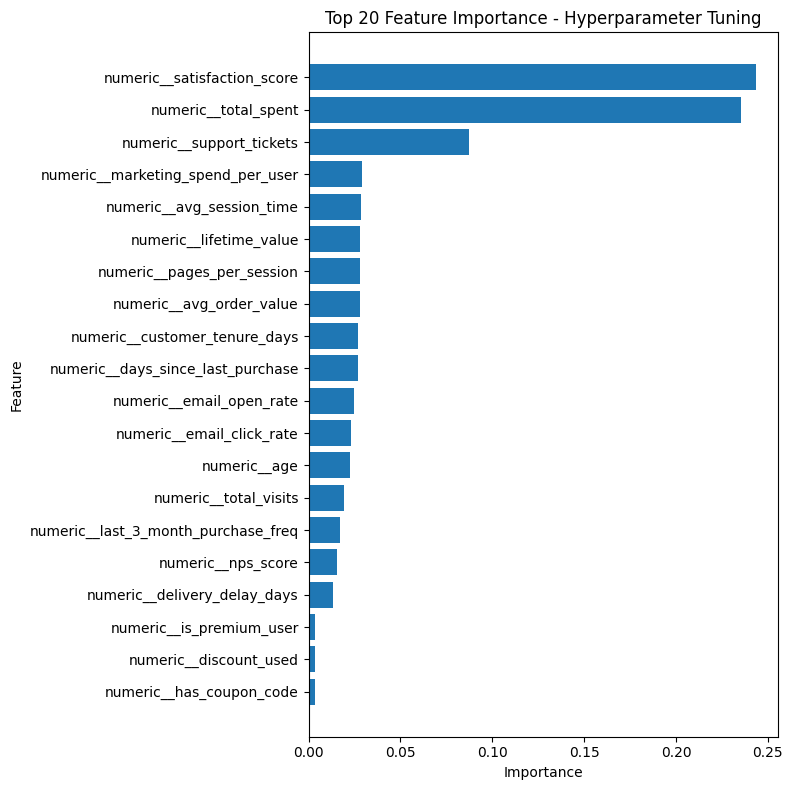

In [20]:
# Visualisasi top 20 feature importance
top_features = feature_importance_df.head(20).sort_values(by="importance")

plt.figure(figsize=(8, 8))
plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top 20 Feature Importance - Hyperparameter Tuning")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_importance_hyperparameter_tuning.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Setup Cross-Validation dan Feature Selector

Cross-validation digunakan pada proses tuning agar model tidak hanya dievaluasi pada satu pembagian data latih saja.

Feature selection dilakukan menggunakan `SelectFromModel` dengan Random Forest sebagai estimator. Feature selector dimasukkan ke dalam pipeline model agar proses seleksi fitur dilakukan di dalam proses training.

In [21]:
# Stratified K-Fold untuk menjaga proporsi kelas pada setiap fold
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Menentukan opsi jumlah fitur maksimal yang akan dipilih
n_features_total = X_train_processed_df.shape[1]

selector_options = sorted(set([
    min(30, n_features_total),
    min(50, n_features_total),
    min(80, n_features_total)
]))

selector_options

[30, 50, 51]

In [22]:
def create_feature_selector():
    """
    Membuat feature selector berbasis Random Forest.
    Threshold -inf digunakan agar pemilihan fitur dikontrol oleh max_features.
    """
    return SelectFromModel(
        estimator=RandomForestClassifier(
            n_estimators=150,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        threshold=-np.inf
    )

## Menyiapkan Model dan Search Space

Tiga model digunakan sesuai skenario sebelumnya:
- Logistic Regression sebagai model konvensional,
- Random Forest sebagai ensemble bagging,
- Voting Classifier sebagai ensemble gabungan.

Pada tahap ini setiap model dimasukkan ke dalam pipeline yang berisi feature selection dan model classifier.

In [23]:
# Pipeline Logistic Regression
logistic_pipeline = Pipeline(steps=[
    ("selector", create_feature_selector()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ))
])

logistic_params = {
    "selector__max_features": selector_options,
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}


# Pipeline Random Forest
random_forest_pipeline = Pipeline(steps=[
    ("selector", create_feature_selector()),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_params = {
    "selector__max_features": selector_options,
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced", "balanced_subsample"]
}


# Pipeline Voting Classifier
voting_pipeline = Pipeline(steps=[
    ("selector", create_feature_selector()),
    ("model", VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("nb", GaussianNB())
        ],
        voting="soft",
        n_jobs=-1
    ))
])

voting_params = {
    "selector__max_features": selector_options,
    "model__lr__C": [0.1, 1, 10],
    "model__lr__class_weight": [None, "balanced"],
    "model__dt__max_depth": [3, 5, 10, None],
    "model__dt__min_samples_leaf": [1, 2, 5],
    "model__dt__class_weight": [None, "balanced"],
    "model__nb__var_smoothing": [1e-9, 1e-8, 1e-7],
    "model__weights": [
        (1, 1, 1),
        (2, 1, 1),
        (1, 2, 1),
        (1, 1, 2),
        (2, 2, 1)
    ]
}


tuning_configs = {
    "Logistic Regression": {
        "pipeline": logistic_pipeline,
        "params": logistic_params,
        "n_iter": 12
    },
    "Random Forest": {
        "pipeline": random_forest_pipeline,
        "params": random_forest_params,
        "n_iter": 15
    },
    "Voting Classifier": {
        "pipeline": voting_pipeline,
        "params": voting_params,
        "n_iter": 12
    }
}

tuning_configs.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'Voting Classifier'])

## Hyperparameter Tuning

Hyperparameter tuning dilakukan menggunakan `RandomizedSearchCV`. Scoring utama yang digunakan adalah F1-Score karena target churn memiliki distribusi kelas yang tidak seimbang.

Model terbaik dari proses tuning kemudian dievaluasi pada data uji.

Hyperparameter tuning: Logistic Regression
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best CV F1-Score: 0.48282238102862474
Best Parameters:
{'selector__max_features': 50, 'model__penalty': 'l1', 'model__class_weight': 'balanced', 'model__C': 0.1}

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.75      0.84      2540
           1       0.35      0.74      0.48       460

    accuracy                           0.75      3000
   macro avg       0.65      0.75      0.66      3000
weighted avg       0.85      0.75      0.78      3000



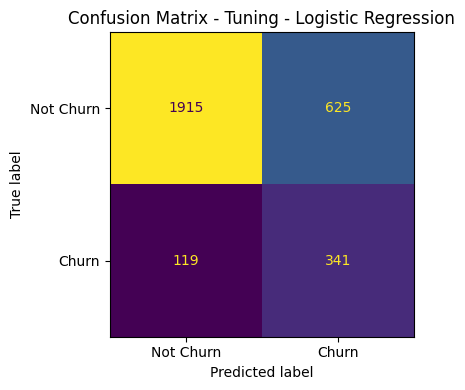

Hyperparameter tuning: Random Forest
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV F1-Score: 0.6603867539671655
Best Parameters:
{'selector__max_features': 50, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 5, 'model__class_weight': 'balanced'}

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.91      2540
           1       0.51      0.97      0.67       460

    accuracy                           0.85      3000
   macro avg       0.75      0.90      0.79      3000
weighted avg       0.92      0.85      0.87      3000



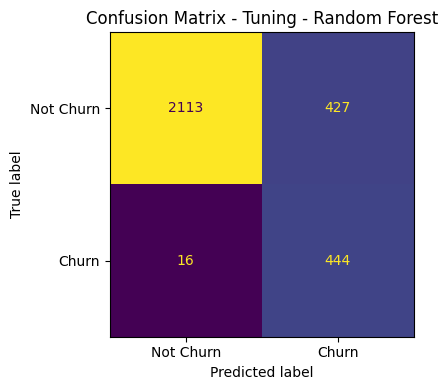

Hyperparameter tuning: Voting Classifier
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best CV F1-Score: 0.6561250399289167
Best Parameters:
{'selector__max_features': 50, 'model__weights': (1, 2, 1), 'model__nb__var_smoothing': 1e-07, 'model__lr__class_weight': 'balanced', 'model__lr__C': 10, 'model__dt__min_samples_leaf': 2, 'model__dt__max_depth': 3, 'model__dt__class_weight': 'balanced'}

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.91      2540
           1       0.51      0.97      0.67       460

    accuracy                           0.86      3000
   macro avg       0.75      0.90      0.79      3000
weighted avg       0.92      0.86      0.87      3000



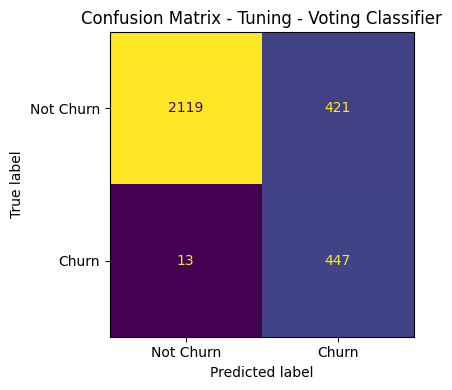

In [24]:
# List untuk menyimpan hasil evaluasi model tuning
tuning_results = []

# Dictionary untuk menyimpan search object dan best estimator
search_objects = {}
best_estimators = {}

for model_name, config in tuning_configs.items():
    print("=" * 80)
    print(f"Hyperparameter tuning: {model_name}")
    
    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=config["n_iter"],
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    
    # Tuning dilakukan hanya pada data latih
    search.fit(X_train_processed_df, y_train)
    
    # Menyimpan hasil search dan best estimator
    search_objects[model_name] = search
    best_estimators[model_name] = search.best_estimator_
    
    print("\nBest CV F1-Score:", search.best_score_)
    print("Best Parameters:")
    print(search.best_params_)
    
    # Evaluasi pada data uji
    y_pred = search.best_estimator_.predict(X_test_processed_df)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    tuning_results.append({
        "Scenario": "Hyperparameter Tuning",
        "Model": model_name,
        "Best CV F1-Score": search.best_score_,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Best Parameters": search.best_params_
    })
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Churn", "Churn"]
    )
    disp.plot(ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - Tuning - {model_name}")
    plt.tight_layout()
    
    safe_model_name = model_name.lower().replace(" ", "_")
    plt.savefig(
        FIGURES_DIR / f"confusion_matrix_tuning_{safe_model_name}.png",
        dpi=150,
        bbox_inches="tight"
    )
    
    plt.show()
    
    # Menyimpan hasil CV setiap model
    cv_results_df = pd.DataFrame(search.cv_results_)
    cv_results_df.to_csv(
        REPORTS_DIR / f"cv_results_tuning_{safe_model_name}.csv",
        index=False
    )

## Hasil Evaluasi Hyperparameter Tuning

Hasil evaluasi dari setiap model tuning disusun ke dalam tabel agar mudah dibandingkan.

In [25]:
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df

,Scenario,Model,Best CV F1-Score,Accuracy,Precision,Recall,F1-Score,Best Parameters
0,Hyperparameter Tuning,Logistic Regression,0.482822,0.752000,0.353002,0.741304,0.478261,"{'selector__max_features': 50, 'model__penalty..."
1,Hyperparameter Tuning,Random Forest,0.660387,0.852333,0.509759,0.965217,0.667168,"{'selector__max_features': 50, 'model__n_estim..."
2,Hyperparameter Tuning,Voting Classifier,0.656125,0.855333,0.514977,0.971739,0.673193,"{'selector__max_features': 50, 'model__weights..."


In [26]:
# Menyimpan hasil evaluasi tuning
tuning_results_df.to_csv(REPORTS_DIR / "hyperparameter_tuning_results.csv", index=False)

print("Hasil evaluasi tuning disimpan ke:")
print(REPORTS_DIR / "hyperparameter_tuning_results.csv")

Hasil evaluasi tuning disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\hyperparameter_tuning_results.csv


## Best Parameters

Bagian ini menampilkan parameter terbaik dari masing-masing model berdasarkan hasil RandomizedSearchCV.

In [27]:
best_params_summary = []

for model_name, search in search_objects.items():
    best_params_summary.append({
        "Model": model_name,
        "Best CV F1-Score": search.best_score_,
        "Best Parameters": search.best_params_
    })

best_params_df = pd.DataFrame(best_params_summary)

best_params_df

,Model,Best CV F1-Score,Best Parameters
0,Logistic Regression,0.482822,"{'selector__max_features': 50, 'model__penalty..."
1,Random Forest,0.660387,"{'selector__max_features': 50, 'model__n_estim..."
2,Voting Classifier,0.656125,"{'selector__max_features': 50, 'model__weights..."


In [28]:
best_params_df.to_csv(REPORTS_DIR / "best_parameters_summary.csv", index=False)

print("Ringkasan best parameters disimpan ke:")
print(REPORTS_DIR / "best_parameters_summary.csv")

Ringkasan best parameters disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\best_parameters_summary.csv


## Model Terbaik Hasil Tuning

Model terbaik hasil tuning dipilih berdasarkan nilai F1-Score pada data uji. F1-Score digunakan karena lebih sesuai untuk kasus churn yang memiliki distribusi kelas tidak seimbang.

In [29]:
best_tuning_result = tuning_results_df.sort_values(
    by="F1-Score",
    ascending=False
).iloc[0]

best_tuning_result

Scenario                                        Hyperparameter Tuning
Model                                               Voting Classifier
Best CV F1-Score                                             0.656125
Accuracy                                                     0.855333
Precision                                                    0.514977
Recall                                                       0.971739
F1-Score                                                     0.673193
Best Parameters     {'selector__max_features': 50, 'model__weights...
Name: 2, dtype: object

In [30]:
best_model_name = best_tuning_result["Model"]
best_tuned_estimator = best_estimators[best_model_name]

print("Model terbaik hasil tuning:", best_model_name)
print("F1-Score:", best_tuning_result["F1-Score"])
print("\nBest Parameters:")
print(search_objects[best_model_name].best_params_)

Model terbaik hasil tuning: Voting Classifier
F1-Score: 0.6731927710843374

Best Parameters:
{'selector__max_features': 50, 'model__weights': (1, 2, 1), 'model__nb__var_smoothing': 1e-07, 'model__lr__class_weight': 'balanced', 'model__lr__C': 10, 'model__dt__min_samples_leaf': 2, 'model__dt__max_depth': 3, 'model__dt__class_weight': 'balanced'}


## Selected Features dari Model Terbaik

Bagian ini menampilkan fitur yang dipilih oleh feature selector pada model terbaik hasil tuning.

In [31]:
best_selector = best_tuned_estimator.named_steps["selector"]
selected_feature_mask = best_selector.get_support()

selected_features = X_train_processed_df.columns[selected_feature_mask].tolist()

selected_features_df = pd.DataFrame({
    "selected_feature": selected_features
})

print("Jumlah fitur terpilih:", len(selected_features))
selected_features_df.head(30)

Jumlah fitur terpilih: 50


,selected_feature
0,numeric__age
1,numeric__is_premium_user
2,numeric__total_visits
3,numeric__avg_session_time
4,numeric__pages_per_session
5,numeric__email_open_rate
6,numeric__email_click_rate
7,numeric__total_spent
8,numeric__avg_order_value
9,numeric__discount_used


In [32]:
selected_features_df.to_csv(
    REPORTS_DIR / "selected_features_best_tuned_model.csv",
    index=False
)

print("Selected features disimpan ke:")
print(REPORTS_DIR / "selected_features_best_tuned_model.csv")

Selected features disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\selected_features_best_tuned_model.csv


## Perbandingan dengan Skenario Sebelumnya

Jika hasil direct modeling dan preprocessing tersedia, hasil hyperparameter tuning akan digabungkan sebagai file perbandingan sementara. Perbandingan final akan dilakukan pada notebook `05_model_comparison.ipynb`.

In [33]:
comparison_frames = []

direct_path = REPORTS_DIR / "direct_modeling_results.csv"
preprocessing_path = REPORTS_DIR / "preprocessing_modeling_results.csv"

if direct_path.exists():
    direct_results_df = pd.read_csv(direct_path)
    comparison_frames.append(direct_results_df)

if preprocessing_path.exists():
    preprocessing_results_df = pd.read_csv(preprocessing_path)
    comparison_frames.append(preprocessing_results_df)

comparison_frames.append(tuning_results_df.drop(columns=["Best Parameters"], errors="ignore"))

model_results_all = pd.concat(comparison_frames, ignore_index=True)

model_results_all.to_csv(REPORTS_DIR / "model_results_all_scenarios.csv", index=False)
model_results_all.to_csv(MODELS_DIR / "model_results.csv", index=False)

display(model_results_all)

print("Hasil perbandingan sementara disimpan ke:")
print(REPORTS_DIR / "model_results_all_scenarios.csv")
print(MODELS_DIR / "model_results.csv")

,Scenario,Model,Accuracy,Precision,Recall,F1-Score,Best CV F1-Score
0,Direct Modeling,Logistic Regression,0.836000,0.289474,0.047826,0.082090,NaN
1,Direct Modeling,Random Forest,0.846667,0.500000,0.008696,0.017094,NaN
2,Direct Modeling,Voting Classifier,0.842333,0.465241,0.189130,0.268934,NaN
3,Preprocessing,Logistic Regression,0.846000,0.493056,0.154348,0.235099,NaN
4,Preprocessing,Random Forest,0.844333,0.480663,0.189130,0.271451,NaN
5,Preprocessing,Voting Classifier,0.847333,0.505376,0.204348,0.291022,NaN
6,Hyperparameter Tuning,Logistic Regression,0.752000,0.353002,0.741304,0.478261,0.482822
7,Hyperparameter Tuning,Random Forest,0.852333,0.509759,0.965217,0.667168,0.660387
8,Hyperparameter Tuning,Voting Classifier,0.855333,0.514977,0.971739,0.673193,0.656125


Hasil perbandingan sementara disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\model_results_all_scenarios.csv
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\models\model_results.csv


## Menyimpan Model Terbaik

Model terbaik hasil tuning disimpan bersama komponen preprocessing yang diperlukan. Penyimpanan dibuat dalam bentuk bundle agar informasi seperti reference date, batas outlier, preprocessor, dan best estimator tetap tersedia untuk tahap deployment.

In [34]:
# Membuat bundle model untuk kebutuhan final dan deployment
best_model_bundle = {
    "model_name": best_model_name,
    "reference_date": reference_date,
    "outlier_cols": outlier_cols,
    "iqr_bounds": iqr_bounds,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "preprocessor": preprocessor,
    "feature_names": feature_names,
    "best_estimator": best_tuned_estimator,
    "selected_features": selected_features,
    "best_parameters": search_objects[best_model_name].best_params_
}

# Menyimpan model bundle
joblib.dump(best_model_bundle, MODELS_DIR / "best_model.pkl")

# Menyimpan estimator saja sebagai dokumentasi tambahan
joblib.dump(best_tuned_estimator, MODELS_DIR / "best_tuned_estimator.pkl")

print("Best model bundle disimpan ke:")
print(MODELS_DIR / "best_model.pkl")

print("\nBest tuned estimator disimpan ke:")
print(MODELS_DIR / "best_tuned_estimator.pkl")

Best model bundle disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\models\best_model.pkl

Best tuned estimator disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\models\best_tuned_estimator.pkl


## Kesimpulan Hyperparameter Tuning

Pada tahap ini, hyperparameter tuning dilakukan pada tiga model, yaitu Logistic Regression, Random Forest, dan Voting Classifier. Proses tuning menggunakan RandomizedSearchCV dengan Stratified K-Fold cross-validation.

Feature importance dianalisis menggunakan Random Forest untuk melihat fitur yang paling berpengaruh. Selain itu, feature selection juga dimasukkan ke dalam pipeline tuning agar model dapat menggunakan fitur yang lebih relevan.

Model terbaik hasil tuning dipilih berdasarkan nilai F1-Score pada data uji. Model tersebut disimpan ke dalam folder `models` bersama komponen preprocessing yang diperlukan.

Hasil tuning ini belum menjadi tahap deployment, tetapi menjadi dasar untuk notebook berikutnya, yaitu `05_model_comparison.ipynb`, yang akan membandingkan seluruh skenario dan menentukan model terbaik secara keseluruhan.